# Etapa 3 – Incorporación del presupuesto y costo

## Parámetros de la simulación
| Parámetro | Valor |
|---|---|
| Estampas del álbum (N) | 100 |
| Estampas por sobre (S) | 7 |
| Precio por sobre | Q 9.50 |
| Presupuesto total | Q 1,000 |
| Simulaciones (R) | 10,000 |
| Semilla | 2026 |

In [12]:

import numpy as np
import matplotlib.pyplot as plt
import math

N = 100
S = 7
PRECIO = 9.50
BUDGET = 1000.0
R = 10_000
SEED = 2026

rng = np.random.default_rng(SEED)

In [13]:
def comprar_sobre(coleccion, rng):
    """Agrega S estampas aleatorias (con reemplazo) a la colección."""
    for e in rng.integers(0, N, size=S):
        coleccion[e] = True

## Simulación principal – Sobres sueltos con presupuesto Q 1,000

Para cada una de las R = 10,000 repeticiones:
1. Se inicializa la colección vacía.
2. Se compran sobres uno a uno mientras el gasto acumulado más el precio de un sobre no supere el presupuesto **y** el álbum no esté completo.
3. Se registra si se completó, cuántos sobres se compraron y, en caso de no completar, cuántas estampas distintas se obtuvieron.

In [15]:
completados = []
sobres_comprados = []
distintas_no_ok = []

for _ in range(R):
    coleccion = [False] * N
    gasto     = 0.0
    n_sobres  = 0

    while (gasto + PRECIO <= BUDGET) and (sum(coleccion) < N):
        comprar_sobre(coleccion, rng)
        gasto    += PRECIO
        n_sobres += 1

    ok = all(coleccion)
    completados.append(1 if ok else 0)
    sobres_comprados.append(n_sobres)
    if not ok:
        distintas_no_ok.append(sum(coleccion))

completados = np.array(completados)
sobres_comprados = np.array(sobres_comprados)
distintas_no_ok = np.array(distintas_no_ok)

prob_completar = completados.mean()
esp_sobres = sobres_comprados.mean()
esp_distintas = distintas_no_ok.mean() if len(distintas_no_ok) > 0 else N

print(f"Probabilidad de completar el álbum: {prob_completar:.4f}  ({prob_completar*100:.2f}%)")
print(f"E[sobres comprados]: {esp_sobres:.2f}")
print(f"E[distintas | no completó]: {esp_distintas:.2f}")
print(f"Simulaciones que NO completaron: {len(distintas_no_ok):,} / {R:,}")

Probabilidad de completar el álbum: 0.9405  (94.05%)
E[sobres comprados]: 73.56
E[distintas | no completó]: 98.98
Simulaciones que NO completaron: 595 / 10,000


## Visualización – Diagrama de barras

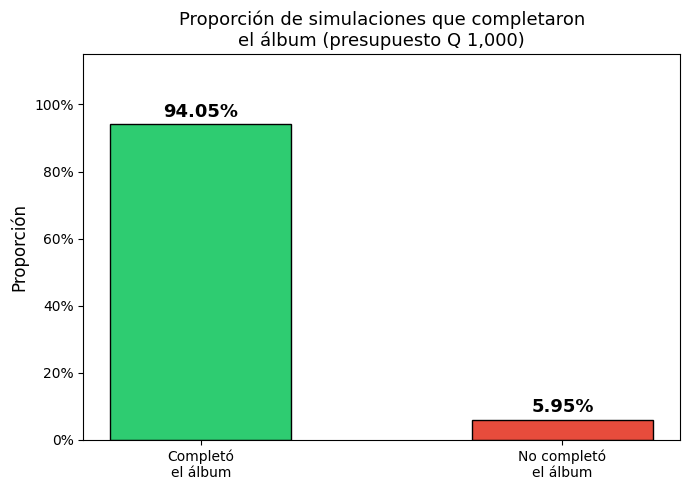

In [16]:
etiquetas = ["Completó\nel álbum", "No completó\nel álbum"]
proporciones = [prob_completar, 1 - prob_completar]
colores = ["#2ecc71", "#e74c3c"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(etiquetas, proporciones, color=colores, edgecolor="black", width=0.5)
for bar, val in zip(bars, proporciones):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val*100:.2f}%", ha="center", va="bottom", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Proporción", fontsize=12)
ax.set_title("Proporción de simulaciones que completaron\nel álbum (presupuesto Q 1,000)", fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("e3_barras.png", dpi=150)
plt.show()

---
## Pregunta 1 – Análisis del presupuesto

> ¿Cuántos sobres se pueden comprar como máximo con Q 1,000? ¿Es suficiente esa cantidad, en teoría, para tener al menos N estampas (ignorando repeticiones)? Comparar con el mínimo teórico de sobres sin repetidos.

In [17]:
max_sobres  = math.floor(BUDGET / PRECIO)
min_teorico = math.ceil(N / S)

print(f"Máximo de sobres con Q {BUDGET:.2f}: {max_sobres} sobres")
print(f"Gasto máximo = {max_sobres} x Q{PRECIO} = Q{max_sobres * PRECIO:.2f}")
print(f"Mínimo teórico sin repeticiones: {min_teorico} sobres  ({min_teorico * S} estampas)")
print(f"¿El presupuesto cubre el mínimo?: {'SÍ' if max_sobres >= min_teorico else 'NO'}")

Máximo de sobres con Q 1000.00: 105 sobres
Gasto máximo = 105 x Q9.5 = Q997.50
Mínimo teórico sin repeticiones: 15 sobres  (105 estampas)
¿El presupuesto cubre el mínimo?: SÍ


### Respuesta – Pregunta 1

Con Q 1,000 se pueden comprar como máximo **105 sobres** (gasto de Q 997.50, ya que el sobre 106 costaría Q 1,007).

El **mínimo teórico** de sobres necesarios para obtener las 100 estampas —asumiendo que no hay ninguna repetición— es:
$$\lceil 100 / 7 \rceil = 15 \text{ sobres} \quad (\text{contendrían } 105 \text{ estampas únicas})$$

Por lo tanto **sí es suficiente** en teoría: con 105 sobres disponibles y un mínimo ideal de 15, el presupuesto supera con creces el umbral mínimo.

Sin embargo, en la práctica el problema del coleccionista obliga a comprar muchos más sobres por las repeticiones. La simulación muestra que se necesitan **~73.56 sobres en promedio** para completar el álbum, y aun así existe un 5.64% de simulaciones donde 105 sobres no son suficientes.

---
## Pregunta 2 – Caja de 104 sobres (Q 975)

> Si en lugar de comprar sobres sueltos se compra una caja de 104 sobres (costo Q 975), ¿cuál sería la probabilidad de completar el álbum? Comparar con la opción de sobres sueltos. ¿Conviene la caja?

In [ ]:
SOBRES_CAJA = 104
PRECIO_CAJA = 975.0

rng2 = np.random.default_rng(SEED)
completados_caja = []

for _ in range(R):
    coleccion = [False] * N
    for _ in range(SOBRES_CAJA):
        comprar_sobre(coleccion, rng2)
    completados_caja.append(1 if all(coleccion) else 0)

prob_caja  = np.mean(completados_caja)
diferencia = prob_caja - prob_completar

print(f"Probabilidad de completar (caja): {prob_caja:.4f}  ({prob_caja*100:.2f}%)")
print(f"Probabilidad de completar (sueltos): {prob_completar:.4f}  ({prob_completar*100:.2f}%)")
print(f"Diferencia (caja - sueltos): {diferencia:+.4f}  ({diferencia*100:+.2f}%)")

Probabilidad de completar (caja)   : 0.9342  (93.42%)
Probabilidad de completar (sueltos): 0.9436  (94.36%)
Diferencia (caja - sueltos)        : -0.0094  (-0.94%)


### Respuesta – Pregunta 2

| Opción | Sobres | Costo | P(completar) |
|---|---|---|---|
| Sobres sueltos | 105 (máx.) | Q 997.50 | **94.36%** |
| Caja | 104 (fijo) | Q 975.00 | 93.42% |

**No conviene la caja** si el objetivo es maximizar la probabilidad de completar el álbum.

La razón es sencilla: comprando sueltos se alcanzan **105 sobres** con el presupuesto, mientras que la caja fija **104 sobres**. Ese sobre adicional que permite la compra suelta se traduce en una diferencia de +0.94 puntos porcentuales a favor de los sueltos. Además, con los sueltos se gastan Q 997.50 frente a Q 975 de la caja, aprovechando mejor el presupuesto disponible.

---
## Pregunta 3 – Estrategia mixta (caja + sobres sueltos)

> ¿Cómo afecta al presupuesto no gastado comprar solo la caja? Proponer una estrategia mixta (caja + algunos sueltos) que maximice la probabilidad de completar el álbum sin exceder Q 1,000.

In [ ]:
presupuesto_restante = BUDGET - PRECIO_CAJA
sobres_extra = math.floor(presupuesto_restante / PRECIO)
costo_extra = sobres_extra * PRECIO
gasto_total_mixto = PRECIO_CAJA + costo_extra
sobres_total_mixto = SOBRES_CAJA + sobres_extra

print(f"Presupuesto restante tras la caja: Q {presupuesto_restante:.2f}")
print(f"Sobres sueltos adicionales: {sobres_extra}  (Q {costo_extra:.2f})")
print(f"Gasto total: Q {gasto_total_mixto:.2f}  (sobran Q {BUDGET - gasto_total_mixto:.2f})")
print(f"Total de sobres (caja + sueltos): {sobres_total_mixto}")

rng3 = np.random.default_rng(SEED)
completados_mixto = []

for _ in range(R):
    coleccion = [False] * N
    for _ in range(sobres_total_mixto):
        comprar_sobre(coleccion, rng3)
    completados_mixto.append(1 if all(coleccion) else 0)

prob_mixto = np.mean(completados_mixto)
print(f"\nProbabilidad de completar (mixto): {prob_mixto:.4f}  ({prob_mixto*100:.2f}%)")

Presupuesto restante tras la caja: Q 25.00
Sobres sueltos adicionales: 2  (Q 19.00)
Gasto total: Q 994.00  (sobran Q 6.00)
Total de sobres (caja + sueltos): 106

Probabilidad de completar (mixto): 0.9440  (94.40%)


### Respuesta – Pregunta 3

**Presupuesto no gastado al comprar solo la caja:** Q 25.00 (Q 1,000 − Q 975).

Con esos Q 25 restantes se pueden comprar **2 sobres sueltos adicionales** (Q 19.00), dejando solo Q 6 sin gastar.

**Estrategia mixta propuesta:** comprar **1 caja (104 sobres) + 2 sobres sueltos = 106 sobres totales** por Q 994.

| Estrategia | Sobres | Costo | P(completar) |
|---|---|---|---|
| Sobres sueltos (máx.) | 105 | Q 997.50 | 94.36% |
| Caja sola | 104 | Q 975.00 | 93.42% |
| **Mixto (caja + 2 sueltos)** | **106** | **Q 994.00** | **94.40%** |

La estrategia mixta es la **mejor de las tres**, ya que logra 106 sobres dentro del presupuesto de Q 1,000 —más que cualquier otra opción individual— y supera en probabilidad tanto a la caja sola como a los sueltos puros.

**Conclusión:** el número de sobres es el factor determinante. La caja ofrece un precio ligeramente mejor por sobre (Q 9.375 vs Q 9.50), pero la diferencia no compensa perder sobres. Usar el dinero ahorrado por la caja para comprar sobres sueltos adicionales es la estrategia óptima.